In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('air_quality.csv').copy()
target_col = 'AQI_Bucket'
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
df.shape

(29531, 16)

In [4]:
df.dtypes

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

In [5]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [6]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df[target_col].value_counts()

AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64

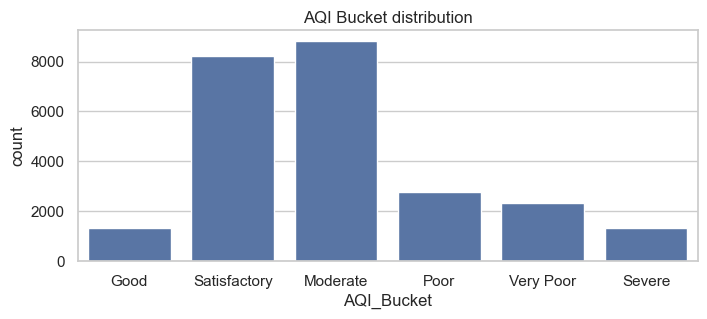

In [9]:
plt.figure(figsize=(8, 3))
sns.countplot(x=target_col, data=df,
              order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe'])
plt.title("AQI Bucket distribution")
plt.show()

In [10]:
# drop non-feature columns
df = df.drop(columns=['City', 'Date', 'AQI'])

In [11]:
# drop rows where target is missing
df = df.dropna(subset=[target_col])

In [12]:
# fill missing feature values with column median
numeric_cols = df.drop(columns=[target_col]).select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [13]:
# encode target label to numeric
quality_map = {
    'Good':         0,
    'Satisfactory': 1,
    'Moderate':     2,
    'Poor':         3,
    'Very Poor':    4,
    'Severe':       5
}
df[target_col] = df[target_col].map(quality_map)

In [14]:
df.isnull().sum()

PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI_Bucket    0
dtype: int64

In [15]:
df.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI_Bucket
28,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,3.14,3
29,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,4.81,4
30,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,7.67,5
31,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,25.87,5
32,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,35.61,5


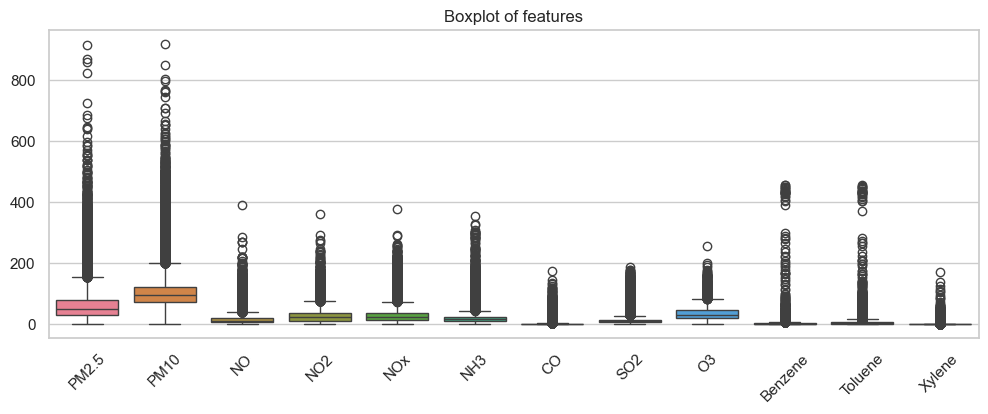

In [ ]:
numeric_cols = df.drop(columns=[target_col]).select_dtypes(include=np.number).columns
df[numeric_cols].fillna(df[numeric_cols].median(),inplace=True)

plt.figure(figsize=(12, 4))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of features")
plt.show()

In [17]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [20]:
pca = PCA(n_components=0.95)
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)

In [21]:
Logistic_param = {'C': [0.01, 0.1, 1, 10]}
model_logistic = LogisticRegression(max_iter=1000, random_state=42)

KNN_param = {'n_neighbors': [3, 5, 7, 9]}
model_knn = KNeighborsClassifier()

SVM_param = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
model_svm = SVC(random_state=42)

Tree_param = {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5]}
model_tree = DecisionTreeClassifier(random_state=42)

RF_param = {'n_estimators': [50, 100], 'max_depth': [3, 5, 10]}
model_rf = RandomForestClassifier(random_state=42)

In [22]:
grid_log = GridSearchCV(model_logistic, Logistic_param, cv=5, n_jobs=-1)
grid_log.fit(X_train, y_train)

grid_knn = GridSearchCV(model_knn, KNN_param, cv=5, n_jobs=-1)
grid_knn.fit(X_train, y_train)

grid_svm = GridSearchCV(model_svm, SVM_param, cv=5, n_jobs=-1)
grid_svm.fit(X_train, y_train)

grid_dt = GridSearchCV(model_tree, Tree_param, cv=5, n_jobs=-1)
grid_dt.fit(X_train, y_train)

grid_rf = GridSearchCV(model_rf, RF_param, cv=5, n_jobs=-1)
grid_rf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'n_estimators': [50, 100]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [23]:
models = [
    ('Logistic',      grid_log),
    ('KNN',           grid_knn),
    ('SVM',           grid_svm),
    ('Decision Tree', grid_dt),
    ('Random Forest', grid_rf),
]

results = []
for name, grid in models:
    y_pred = grid.best_estimator_.predict(X_test)
    results.append({
        'Model':         name,
        'Best Params':   grid.best_params_,
        'CV Best Score': round(grid.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Best Params,CV Best Score,Test Accuracy
0,SVM,"{'C': 10, 'kernel': 'rbf'}",0.7781,0.7769
1,KNN,{'n_neighbors': 7},0.7550,0.7573
2,Random Forest,"{'max_depth': 10, 'n_estimators': 100}",0.7470,0.7493
3,Logistic,{'C': 10},0.7520,0.7477
4,Decision Tree,"{'max_depth': 10, 'min_samples_split': 5}",0.7044,0.7068


In [24]:
results_df.loc[[0]]

,Model,Best Params,CV Best Score,Test Accuracy
0,SVM,"{'C': 10, 'kernel': 'rbf'}",0.7781,0.7769
